<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Stochastic-Simulations/blob/master/Zadanie_2_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

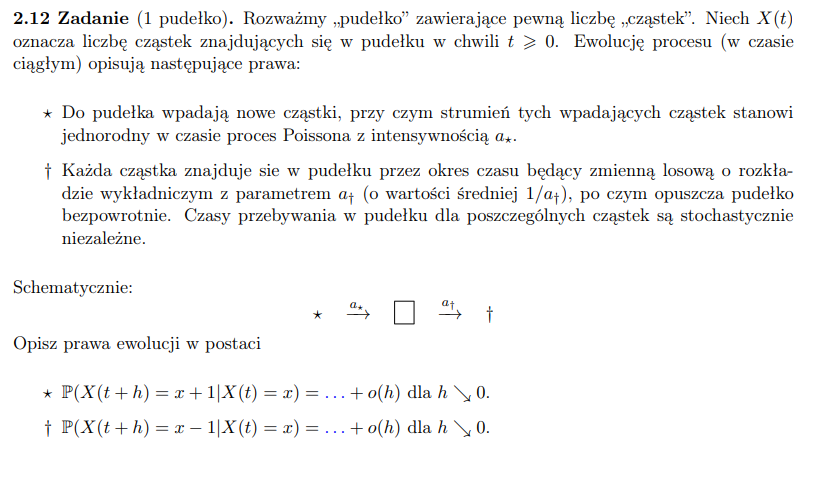

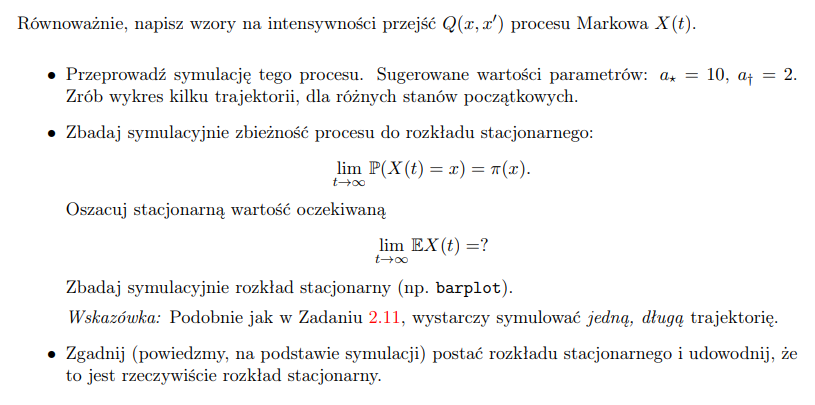

### Setup
---
Let us observe that the evalution of the process behaves as follows when $h \rightarrow 0$:
$$\star \space P(X(t + h) = x + 1|X(t) = x) = a_⋆h + o(h) $$
$$\dagger \space P(X(t + h) = x - 1|X(t) = x) = xa_\dagger h + o(h) $$


Equivalently, we may write is in intensity matrix $Q$ terminology:

$$q_{x,x+1} = a_\star$$
$$q_{x-1,x} = xa_\dagger \space \space \space (\text{for} \space x \geq 0)$$
$$q_{x,x} = -(a_\star + xa_\dagger)$$



### Simulations
---

#### Trajectory simulation
---

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [8]:
def gillespie_sampler(a_star, a_dagger, X0, T_max):
    t = [0.0]
    X = [X0]

    while t[-1] < T_max:
        current_X = X[-1]

        # updating intensivities
        rate_up = a_star
        rate_down = a_dagger * current_X

        total_rate = rate_up + rate_down

        if total_rate == 0:
            break

        # sampling moments of events
        dt = np.random.exponential(1.0 / total_rate)
        t.append(t[-1] + dt)

        # sampling type of event
        if np.random.rand() < rate_up / total_rate:
            X.append(current_X + 1)
        else:
            X.append(current_X - 1)

    return np.array(t), np.array(X)

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_7423/2952705515.py:11: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'Stochastic trajectories ($a_\star={a_star}, a_\dagger={a_dagger}$)')
/tmp/ipykernel_7423/2952705515.py:11: SyntaxWarning: invalid escape sequence '\d'
  plt.title(f'Stochastic trajectories ($a_\star={a_star}, a_\dagger={a_dagger}$)')


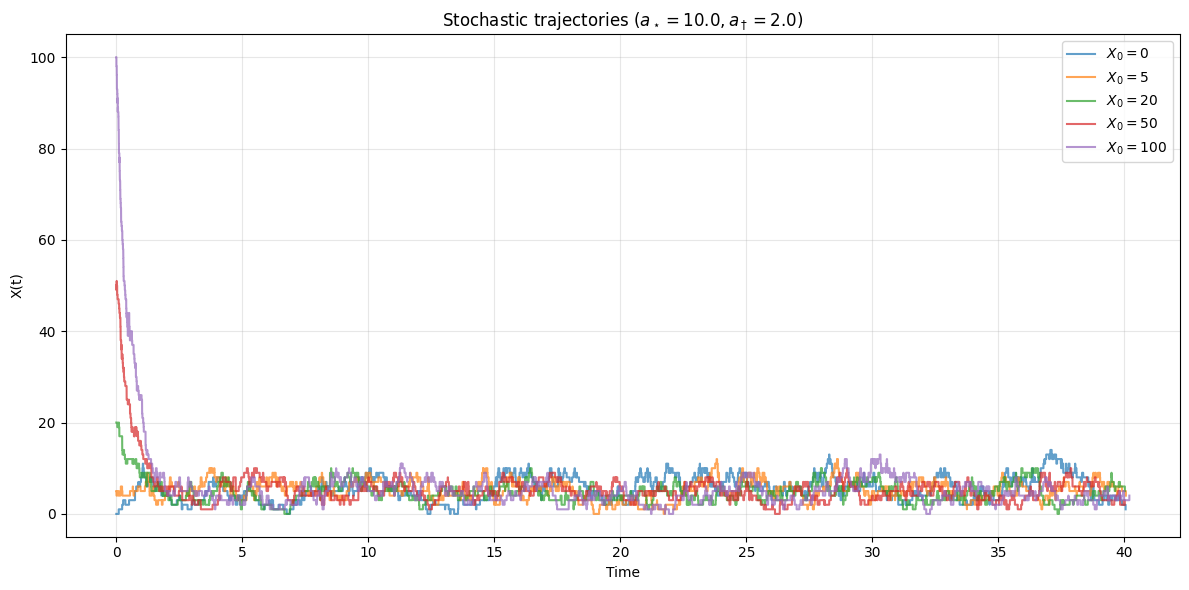

In [12]:
a_star = 10.0
a_dagger = 2.0
X0 = [0, 5, 20, 50, 100]
T_max = 40.0

plt.figure(figsize=(12, 6))
for x0 in X0:
    t_sim, X_sim = gillespie_sampler(a_star, a_dagger, x0, T_max)
    plt.step(t_sim, X_sim, where='post', alpha=0.7, linewidth=1.5, label=f'$X_0={x0}$')

plt.title(f'Stochastic trajectories ($a_\star={a_star}, a_\dagger={a_dagger}$)')
plt.xlabel('Time')
plt.ylabel('X(t)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Stationary distribution estimation
----

In [15]:
T_max = 100000
t_sim, X_sim = gillespie_sampler(a_star=a_star, a_dagger=a_dagger, X0=0, T_max=T_max)

<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_7423/3770506980.py:24: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(states_range, poisson_pmf, 'ro-', label=f'Theoretical Poisson distribution ($\lambda={lam}$)')
/tmp/ipykernel_7423/3770506980.py:28: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\pi(x)$', fontsize=12)


Estimated stationary distrubution: [6.71955521e-03 3.33303404e-02 8.38423009e-02 1.40139812e-01
 1.76064675e-01 1.75847883e-01 1.46730716e-01 1.04204070e-01
 6.53404220e-02 3.60729128e-02 1.80079072e-02 8.24289196e-03
 3.44577290e-03 1.35394638e-03 4.63145179e-04 1.43143934e-04
 3.37387496e-05 1.30766553e-05 3.56370337e-06 5.99156878e-07]
Estimated EX: 5.001295173292839


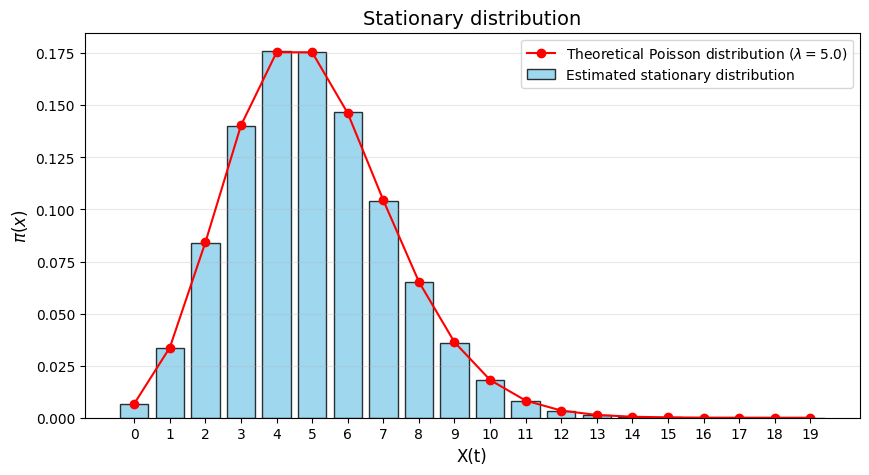

In [18]:
holding_times = np.diff(t_sim)
visited_states = X_sim[:-1]

# obtaining maximum number of particles
x_max = np.max(visited_states)
states_range = np.arange(0, x_max + 1)

# computing the estimation for pi
time_spent_in_states = np.bincount(visited_states, weights=holding_times)
pi_est = time_spent_in_states / T_max
print("Estimated stationary distrubution:", pi_est)

# computing EX
expected_X = np.sum(states_range * pi_est)
print('Estimated EX:', expected_X)

# Barplot
plt.figure(figsize=(10, 5))
plt.bar(states_range, pi_est, color='skyblue', edgecolor='black', alpha=0.8, label='Estimated stationary distribution')

# guessed theoretical distribution - Poisson
lam = a_star / a_dagger
poisson_pmf = stats.poisson.pmf(states_range, lam)
plt.plot(states_range, poisson_pmf, 'ro-', label=f'Theoretical Poisson distribution ($\lambda={lam}$)')

plt.title('Stationary distribution', fontsize=14)
plt.xlabel('X(t)', fontsize=12)
plt.ylabel('$\pi(x)$', fontsize=12)
plt.xticks(states_range)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

#### Theoretical stationary distribution
---
In the previous step we guessed that the theoretical stationary distribution is the Poisson distribution with parameter $\frac{a_\star}{a_\dagger}=10/2=5$.

Now, it is time to prove that this is true. In the birth-death process, the stationary distribution must satisfy balance equations, which state that transitions from state x to state x+1 must be balanced with transitions from state x+1 to state x:

$$\pi(x) \cdot q_{x, x+1} = \pi(x+1) \cdot q_{x+1, x}$$

Now, we can rewrite this equation:

$$\pi(x) \cdot a_\star = \pi(x+1) \cdot (x+1) a_\dagger$$
$$\pi(x+1) = \frac{a_\star}{a_\dagger} \cdot \frac{1}{x+1} \cdot \pi(x)$$

Applying this recursively:
$$\pi(x+1) = \left(\frac{a_\star}{a_\dagger}\right)^{x+1} \cdot \frac{1}{(x+1)!} \cdot \pi(0)$$

Since $\sum_{n=0}^{∞}\pi(n)=1$, we may compute that $\pi(0)=e^{-a_\star/a_\dagger}$. Finally, we obtain that:

$$\pi(x) = \left(\frac{a_\star}{a_\dagger}\right)^{x} \cdot \frac{1}{x!} \cdot e^{-a_\star/a_\dagger},$$

which is exactly the probability mass function of the Poisson distribution with parameter $\frac{a_\star}{a_\dagger}$.